In [3]:
# =========================================================
# NOTEBOOK: 14_transformer_bert.ipynb
# =========================================================

# =========================================================
# STEP 1 — IMPORT LIBRARIES
# =========================================================

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

import torch

from transformers import (
    BertTokenizer,
    BertForSequenceClassification,
    Trainer,
    TrainingArguments
)

from datasets import Dataset

import warnings

warnings.filterwarnings('ignore')

print("Libraries Imported Successfully")


Libraries Imported Successfully


In [4]:
# =========================================================
# STEP 2 — DEVICE CONFIGURATION
# =========================================================

device = torch.device(
    'cuda' if torch.cuda.is_available() else 'cpu'
)

print("Using Device:", device)

Using Device: cpu


In [5]:
# =========================================================
# STEP 3 — LOAD DATASET
# =========================================================

reviews_df = pd.read_csv(
    r"C:\Users\niran\Desktop\AI_Ecommerce_Customer_Intelligence_Platform\data\raw\order_reviews.csv"
)

print(reviews_df.shape)

reviews_df.head()

(933748, 7)


,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,0ba49642-47bb-4817-9cc2-bb9ded7de7c5,c0142972-63fa-4af2-8070-f583ab769847,5,Perfect,The quality is amazing. Delivery was quick.,2019-06-19 05:08:44,2019-06-19 07:08:44
1,4e540350-1d67-4f18-bfbb-66e45e16bbc5,11bdf634-2b87-4d37-8d76-be1e7aff8f3b,5,Good,The service is excellent. Super fast shipping.,2023-04-12 23:42:33,2023-04-13 01:42:33
2,9bf68eb6-676d-4759-956e-564b7b90410c,d29b58ad-af2a-47b4-9214-b2664fb1fdba,5,Perfect,The item is fantastic. Arrived early!,2023-02-08 15:26:24,2023-02-08 17:26:24
3,17619bc8-a922-4c55-9ea6-fb027511e2fb,3d4a035e-588c-4ebd-ab6c-bf06a38cff10,5,Great,The product is good. Delivery was quick.,2022-01-26 22:36:58,2022-01-27 00:36:58
4,e41030af-afab-41f7-9a28-0098de875634,d7537ba2-da79-4a25-abaa-0b9a28452645,5,Perfect,The item is fantastic. Super fast shipping.,2021-12-18 19:09:26,2021-12-18 21:09:26


In [6]:
# =========================================================
# STEP 4 — SELECT NLP COLUMNS
# =========================================================

nlp_df = reviews_df[[
    'review_comment_message',
    'review_score'
]]

nlp_df = nlp_df.dropna()

nlp_df.head()

,review_comment_message,review_score
0,The quality is amazing. Delivery was quick.,5
1,The service is excellent. Super fast shipping.,5
2,The item is fantastic. Arrived early!,5
3,The product is good. Delivery was quick.,5
4,The item is fantastic. Super fast shipping.,5


In [7]:
print(nlp_df.shape)

print(nlp_df['review_score'].value_counts())

(933748, 2)
review_score
5    469318
4    234499
2    115300
3     68823
1     45808
Name: count, dtype: int64


In [8]:
# =========================================================
# STEP 5 — CREATE SENTIMENT LABELS
# =========================================================

def create_sentiment(score):

    if score >= 4:
        return 2   # Positive

    elif score == 3:
        return 1   # Neutral

    else:
        return 0   # Negative

nlp_df['sentiment'] = nlp_df[
    'review_score'
].apply(create_sentiment)

print(nlp_df['sentiment'].value_counts())

sentiment
2    703817
0    161108
1     68823
Name: count, dtype: int64


In [9]:
# =========================================================
# STEP 6 — RENAME COLUMNS
# =========================================================

nlp_df = nlp_df.rename(columns={
    'review_comment_message': 'text',
    'sentiment': 'label'
})

nlp_df = nlp_df[['text', 'label']]

nlp_df.head()

,text,label
0,The quality is amazing. Delivery was quick.,2
1,The service is excellent. Super fast shipping.,2
2,The item is fantastic. Arrived early!,2
3,The product is good. Delivery was quick.,2
4,The item is fantastic. Super fast shipping.,2


In [36]:
# =========================================================
# STEP 7 — SAMPLE DATASET
# =========================================================

# IMPORTANT:
# Use sampling for manageable training

nlp_df = nlp_df.sample(
    n=min(5000, len(nlp_df)),
    random_state=42
)

print(nlp_df.shape)

(5000, 2)


In [37]:
# =========================================================
# STEP 8 — TRAIN TEST SPLIT
# =========================================================

train_df, test_df = train_test_split(
    nlp_df,
    test_size=0.2,
    random_state=42,
    stratify=nlp_df['label']
)

print(train_df.shape)
print(test_df.shape)

(4000, 2)
(1000, 2)


In [38]:
# =========================================================
# STEP 9 — LOAD TOKENIZER
# =========================================================

tokenizer = BertTokenizer.from_pretrained(
    'bert-base-uncased'
)

print("Tokenizer Loaded")

Tokenizer Loaded


In [39]:
# =========================================================
# STEP 10 — TOKENIZATION FUNCTION
# =========================================================

def tokenize_function(examples):

    return tokenizer(
        examples['text'],
        padding='max_length',
        truncation=True,
        max_length=128
    )

In [40]:
# =========================================================
# STEP 11 — CONVERT TO HF DATASET
# =========================================================

train_dataset = Dataset.from_pandas(
    train_df
)

test_dataset = Dataset.from_pandas(
    test_df
)

print(train_dataset)

Dataset({
    features: ['text', 'label', '__index_level_0__'],
    num_rows: 4000
})


In [41]:
# =========================================================
# STEP 12 — TOKENIZE DATASET
# =========================================================

train_dataset = train_dataset.map(
    tokenize_function,
    batched=True
)

test_dataset = test_dataset.map(
    tokenize_function,
    batched=True
)

print("Tokenization Completed")

Map:   0%|          | 0/4000 [00:00<?, ? examples/s]

Map:   0%|          | 0/1000 [00:00<?, ? examples/s]

Tokenization Completed


In [42]:
# =========================================================
# STEP 13 — FORMAT DATASET
# =========================================================

train_dataset.set_format(
    type='torch',
    columns=[
        'input_ids',
        'attention_mask',
        'label'
    ]
)

test_dataset.set_format(
    type='torch',
    columns=[
        'input_ids',
        'attention_mask',
        'label'
    ]
)

print("Dataset Formatting Completed")

Dataset Formatting Completed


In [43]:
# =========================================================
# STEP 14 — LOAD BERT MODEL
# =========================================================

model = BertForSequenceClassification.from_pretrained(
    'bert-base-uncased',
    num_labels=3
)

model.to(device)

print("BERT Model Loaded")

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


BERT Model Loaded


In [44]:
# =========================================================
# STEP 15 — METRICS FUNCTION
# =========================================================

def compute_metrics(eval_pred):

    logits, labels = eval_pred

    predictions = np.argmax(
        logits,
        axis=-1
    )

    accuracy = accuracy_score(
        labels,
        predictions
    )

    precision = precision_score(
        labels,
        predictions,
        average='weighted'
    )

    recall = recall_score(
        labels,
        predictions,
        average='weighted'
    )

    f1 = f1_score(
        labels,
        predictions,
        average='weighted'
    )

    return {
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1
    }

In [45]:
# =========================================================
# STEP 16 — TRAINING ARGUMENTS
# =========================================================

training_args = TrainingArguments(

    output_dir='./bert_results',

    do_train=True,

    do_eval=True,

    learning_rate=2e-5,

    per_device_train_batch_size=4,

    per_device_eval_batch_size=4,

    num_train_epochs=1,

    weight_decay=0.01,

    logging_dir='./logs',

    logging_steps=100,

    save_steps=500,

    report_to=[]
)

In [46]:
import transformers

print(transformers.__version__)

4.52.4


In [47]:
# =========================================================
# STEP 17 — TRAINER
# =========================================================

trainer = Trainer(
    model=model,

    args=training_args,

    train_dataset=train_dataset,

    eval_dataset=test_dataset,

    compute_metrics=compute_metrics
)

print("Trainer Initialized")

Trainer Initialized


In [48]:
# =========================================================
# STEP 18 — TRAIN MODEL
# =========================================================

trainer.train()

Step,Training Loss
100,0.273500
200,0.004700
300,0.001500
400,0.000900
500,0.000700
600,0.000600
700,0.000500
800,0.000400
900,0.000400
1000,0.000400


TrainOutput(global_step=1000, training_loss=0.028357160609215497, metrics={'train_runtime': 4864.3928, 'train_samples_per_second': 0.822, 'train_steps_per_second': 0.206, 'total_flos': 263113417728000.0, 'train_loss': 0.028357160609215497, 'epoch': 1.0})

In [49]:
# =========================================================
# STEP 20 — PREDICTIONS
# =========================================================

predictions = trainer.predict(
    test_dataset
)

y_pred = np.argmax(
    predictions.predictions,
    axis=1
)

y_true = predictions.label_ids

print(y_pred[:10])

[2 2 2 0 2 2 2 2 0 2]


In [50]:
# =========================================================
# STEP 21 — CLASSIFICATION REPORT
# =========================================================

print(
    classification_report(
        y_true,
        y_pred
    )
)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       171
           1       1.00      1.00      1.00        79
           2       1.00      1.00      1.00       750

    accuracy                           1.00      1000
   macro avg       1.00      1.00      1.00      1000
weighted avg       1.00      1.00      1.00      1000



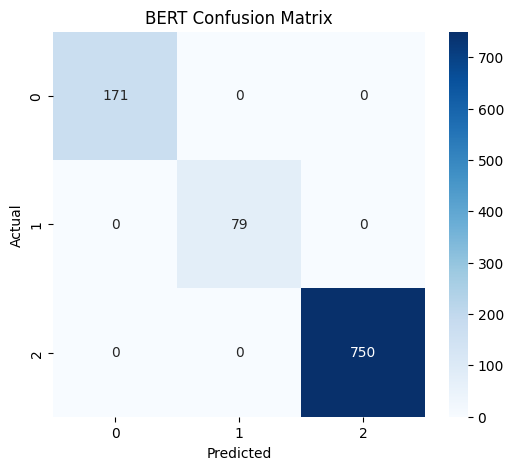

In [51]:
# =========================================================
# STEP 22 — CONFUSION MATRIX
# =========================================================

cm = confusion_matrix(
    y_true,
    y_pred
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("BERT Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

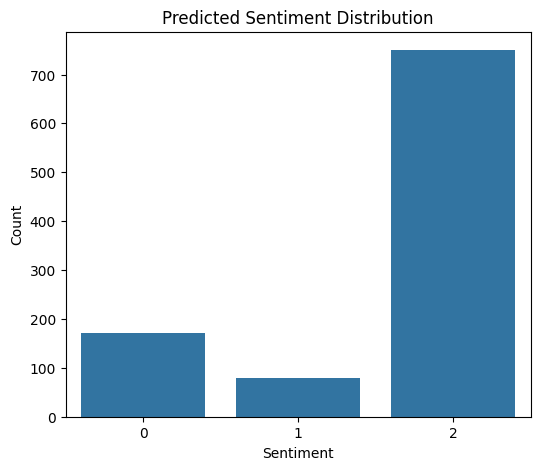

In [52]:
# =========================================================
# STEP 23 — SENTIMENT DISTRIBUTION
# =========================================================

sentiment_counts = pd.Series(
    y_pred
).value_counts()

plt.figure(figsize=(6,5))

sns.barplot(
    x=sentiment_counts.index,
    y=sentiment_counts.values
)

plt.title("Predicted Sentiment Distribution")

plt.xlabel("Sentiment")

plt.ylabel("Count")

plt.show()

In [ ]:
# =========================================================
# STEP 24 — SAVE MODEL
# =========================================================

bert_dir = MODELS_DIR / "bert_sentiment_model"

bert_dir.mkdir(parents=True, exist_ok=True)

model.save_pretrained(bert_dir)

tokenizer.save_pretrained(bert_dir)

print("BERT Model Saved Successfully")

BERT Model Saved Successfully


In [54]:
# =========================================================
# STEP 25 — SAMPLE INFERENCE
# =========================================================

sample_text = "The delivery was very fast and product quality was excellent"

inputs = tokenizer(
    sample_text,
    return_tensors='pt',
    truncation=True,
    padding=True,
    max_length=128
)

inputs = {
    k: v.to(device)
    for k, v in inputs.items()
}

with torch.no_grad():

    outputs = model(**inputs)

prediction = torch.argmax(
    outputs.logits,
    dim=1
).item()

sentiment_map = {
    0: 'Negative',
    1: 'Neutral',
    2: 'Positive'
}

print("Review:", sample_text)

print("Predicted Sentiment:", sentiment_map[prediction])

Review: The delivery was very fast and product quality was excellent
Predicted Sentiment: Positive


In [55]:
# =========================================================
# STEP 26 — BUSINESS INSIGHTS
# =========================================================

print("""

===================================================

BUSINESS INSIGHTS

===================================================

1. Built Transformer-based NLP Intelligence System.

2. Fine-tuned BERT model for sentiment analysis.

3. Classified customer reviews into:
   - Positive
   - Neutral
   - Negative

4. Generated NLP-driven business insights.

5. System can support:
   - Customer experience analytics
   - Seller quality monitoring
   - Product feedback analysis
   - Refund-risk detection
   - Delivery issue monitoring

6. Used:
   - Transformer architecture
   - Attention mechanism
   - HuggingFace ecosystem

7. Saved trained BERT model for deployment.

===================================================

""")




BUSINESS INSIGHTS


1. Built Transformer-based NLP Intelligence System.

2. Fine-tuned BERT model for sentiment analysis.

3. Classified customer reviews into:
   - Positive
   - Neutral
   - Negative

4. Generated NLP-driven business insights.

5. System can support:
   - Customer experience analytics
   - Seller quality monitoring
   - Product feedback analysis
   - Refund-risk detection
   - Delivery issue monitoring

6. Used:
   - Transformer architecture
   - Attention mechanism
   - HuggingFace ecosystem

7. Saved trained BERT model for deployment.





In [56]:
# =========================================================
# STEP 27 — NOTEBOOK COMPLETION
# =========================================================

print("""

===================================================
14_transformer_bert.ipynb COMPLETED SUCCESSFULLY
===================================================

""")



14_transformer_bert.ipynb COMPLETED SUCCESSFULLY


